In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

#Upload das imagens

In [4]:
upload =  files.upload()

Saving normal.jpeg to normal.jpeg


#Print das imagens normais


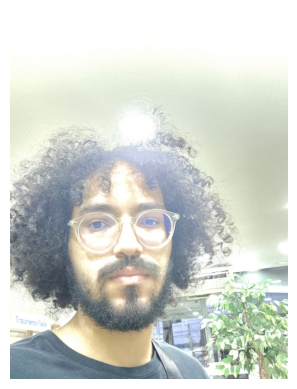

In [5]:
img_estourada = cv2.imread('estourada.jpeg')
plt.imshow(cv2.cvtColor(img_estourada, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

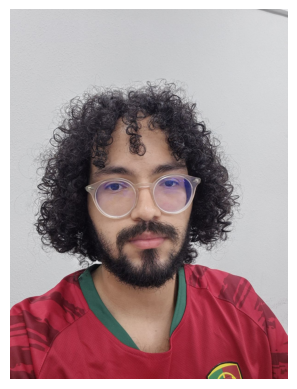

In [6]:
img_normal = cv2.imread('normal.jpeg')
plt.imshow(cv2.cvtColor(img_normal, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

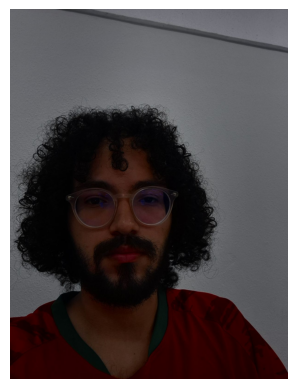

In [7]:
img_escurecida = cv2.imread('escurecida.jpeg')
plt.imshow(cv2.cvtColor(img_escurecida, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

#Imagens em escala de cinza

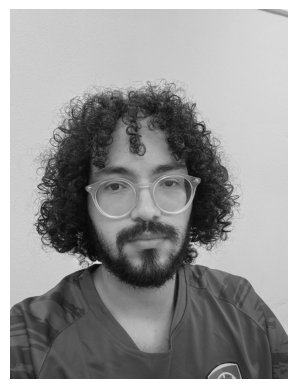

In [8]:
img_normal_gray = cv2.cvtColor(img_normal,cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(img_normal_gray, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

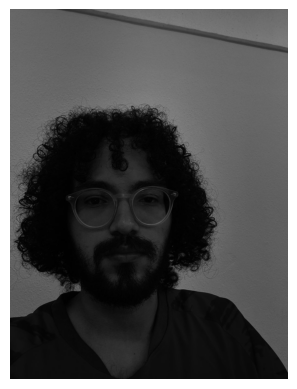

In [11]:
img_escurecida_gray = cv2.cvtColor(img_escurecida,cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(img_escurecida_gray, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

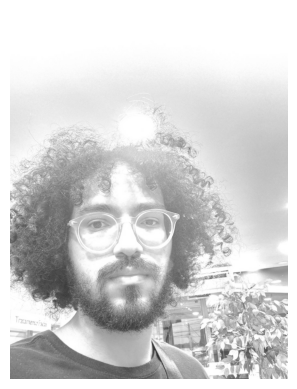

In [12]:
img_estourada_gray = cv2.cvtColor(img_estourada,cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(img_estourada_gray, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

#Calculo e plotagem de histogramas

In [13]:
def calc_hist(img):
  img_vetor = img.ravel() #pode usar flatten
  hist_vetor = np.zeros(256, dtype=np.int64)

  for px in img_vetor:
    hist_vetor[px] += 1

  return hist_vetor

<BarContainer object of 256 artists>

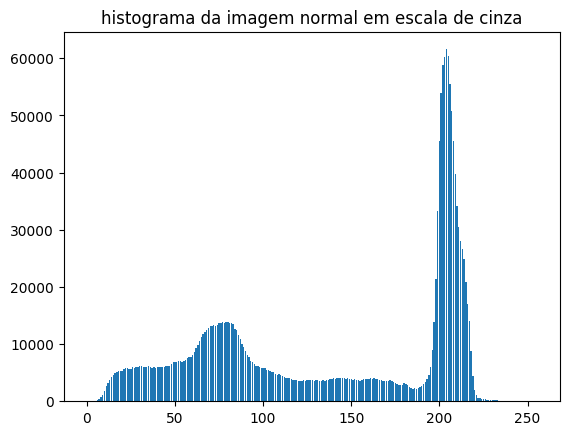

In [65]:
hist_img_normal = calc_hist(img_normal_gray)

plt.title('histograma da imagem normal em escala de cinza')
plt.bar(range(256),hist_img_normal)

Explicação

Por ser uma imagem com luminação "boa", o equilibrio dos pixels mesmo tendo escala de cinza, entretanto possui mas partes beirando o brando, provavelmente por conta do fundo da foto ser uma parede branca

<BarContainer object of 256 artists>

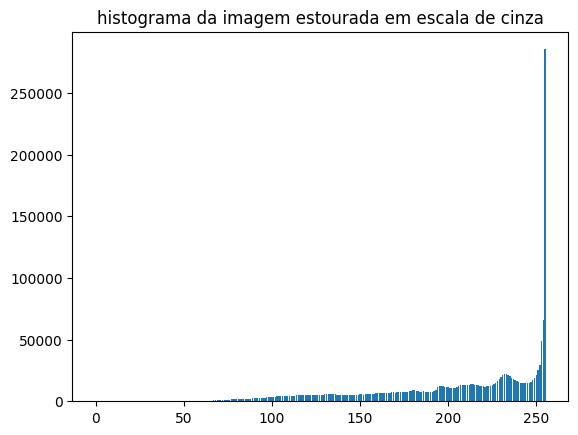

In [66]:
hist_img_estourada = calc_hist(img_estourada_gray)

plt.title('histograma da imagem estourada em escala de cinza')
plt.bar(range(256),hist_img_estourada)

Explicação

Por ser estourada a tendencia é realmente que ela fique tendenciosa para o 250 por conta que por ter um foco de luz maior quando vai para a escala de cinza o que já estada "estourada" fica branco e os pixels ao redor também.

<BarContainer object of 256 artists>

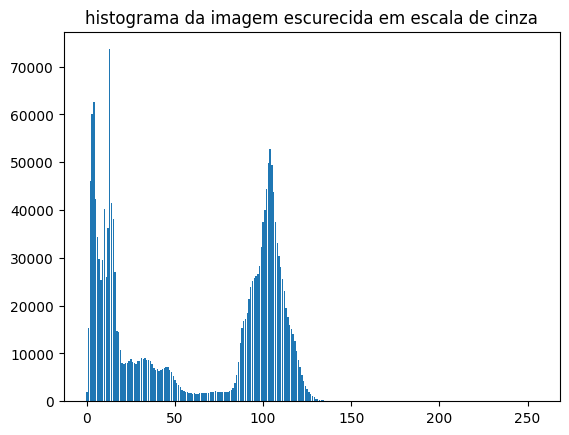

In [51]:
hist_img_escurecida = calc_hist(img_escurecida_gray)

plt.title('histograma da imagem escurecida em escala de cinza')
plt.bar(range(256),hist_img_escurecida)

Explicação

A escurecida acontece o contrario da estourada, os pixels ficam focados mais perto do zero, no preto, entretanto como o fundo é branco mesmo estando escurecida e na escala cinza ainda temos alguns pixels "claros" por conta disso

#Aplicação da operação

A operação escolhida foi a equalização de histograma

Explicação:<br>
Ela foi escolhida pois analisando as três fotos princiaplmente a foto escurecida e a foto estourada elas são opostos em relaçao ao seu histograma como só posso utilizar um metodo para todos, se eu escolhesse o metodo de constraste a foto escurecida ficaria boa, porém a foto estourada ficaria teria uma melhora gratificante na imagem e na correção de GAMMA eu teria que mudar a varivel para variveis opostos para as fotos escurecidas e estouradas,pois se utilizasse a mesma y para todas alguma ficaria ruim.<br>
Tecnicamente foi utilizado a varivel L, onde ela representa o 256 na formula de calculo, que seria o numero maximo para calcular a intensidade de um pixel no padrão RGB. Mas na pratica ele utiliza o mapeamento de histograma e tenta deixar os pixels mais homogeneos na parte do meio do histograma

In [54]:
def equalizacao_histograma_manual(imagem):
    """
    Equaliza o histograma manualmente.

    Espera uma imagem em tons de cinza (uint8).
    """
    histograma = np.zeros(256, dtype=int)

    # Calcula o histograma
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            nivel = imagem[i, j]
            histograma[nivel] += 1

    # Calcula a distribuição acumulada (CDF)
    cdf = np.cumsum(histograma)

    # Normaliza a CDF para o intervalo [0, 255]
    cdf_normalizada = 255 * cdf / cdf[-1]

    resultado = np.zeros_like(imagem)

    # Substitui cada pixel pelo novo nível de cinza
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            resultado[i, j] = cdf_normalizada[imagem[i, j]]

    return resultado.astype(np.uint8)


def equalizacao_histograma_opencv(imagem):
    """
    Equaliza o histograma usando a função pronta do OpenCV.
    """
    return cv2.equalizeHist(imagem)


##Imagem normal

<BarContainer object of 256 artists>

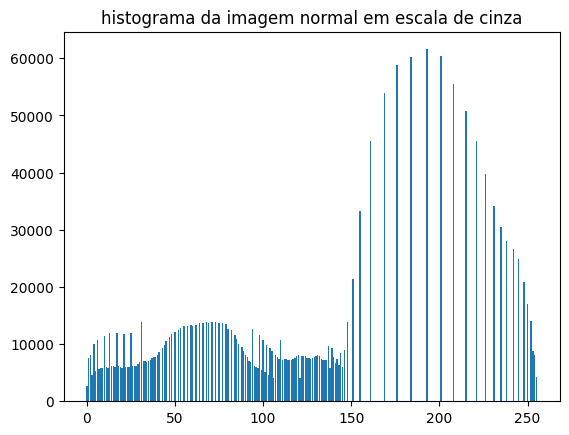

In [63]:
nova_imagem_normal = equalizacao_histograma_opencv(img_normal_gray)

hist_img_normal_equalizada = calc_hist(nova_imagem_normal)

plt.title('histograma da imagem normal em escala de cinza')
plt.bar(range(256),hist_img_normal_equalizada)

<BarContainer object of 256 artists>

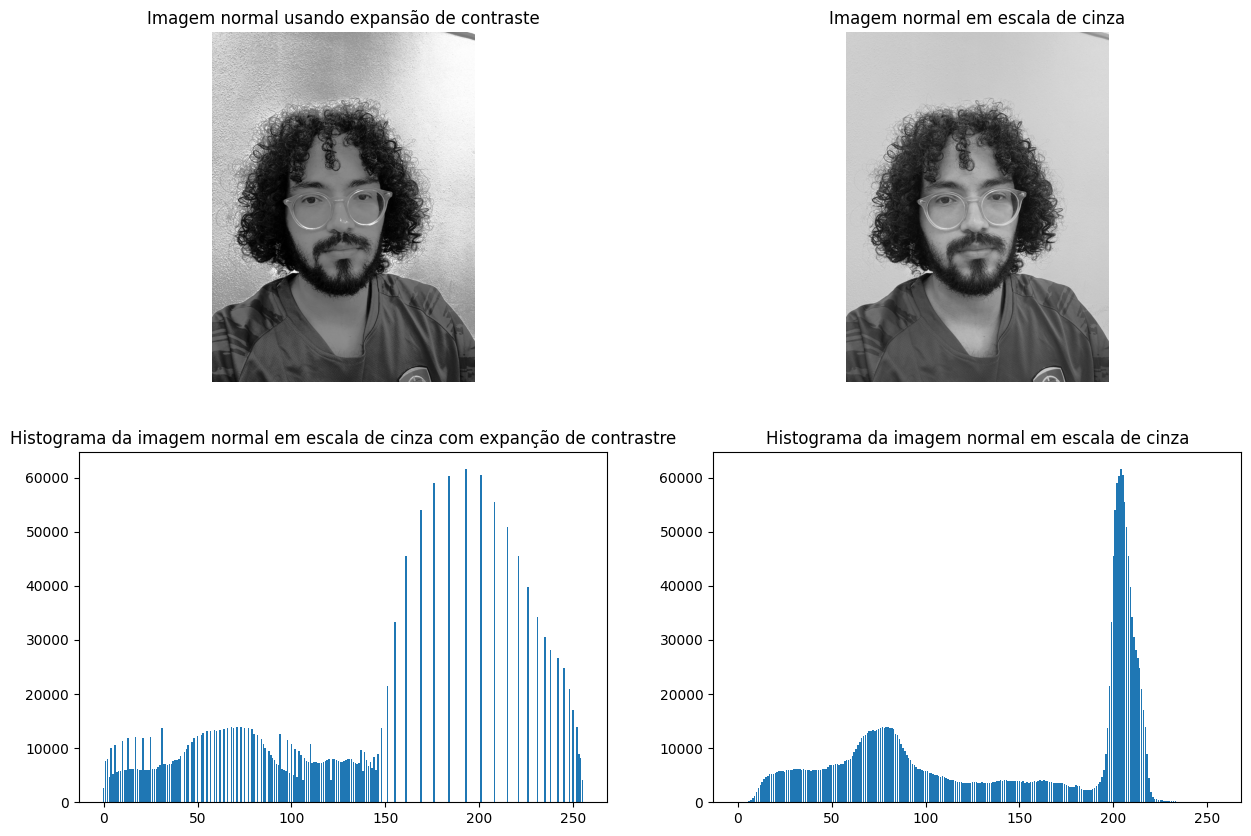

In [67]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.title('Imagem normal usando expansão de contraste')
plt.imshow(cv2.cvtColor(nova_imagem_normal, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,2,2)
plt.title('Imagem normal em escala de cinza')
plt.imshow(cv2.cvtColor(img_normal_gray, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,2,3)
plt.title('Histograma da imagem normal em escala de cinza com expanção de contrastre')
plt.bar(range(256),hist_img_normal_equalizada)

plt.subplot(2,2,4)
plt.title('Histograma da imagem normal em escala de cinza')
plt.bar(range(256),hist_img_normal)

##Imagem escurecida


<BarContainer object of 256 artists>

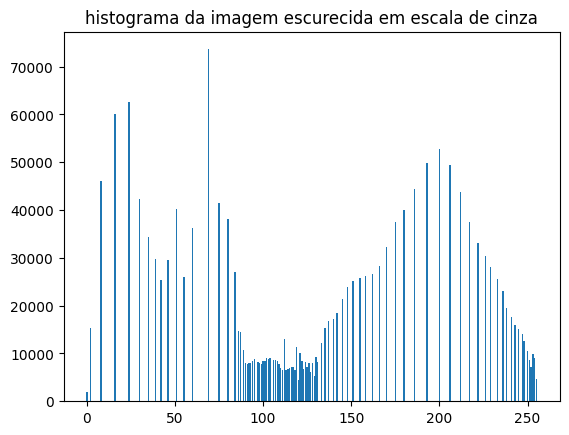

In [60]:
nova_imagem_escurecida = equalizacao_histograma_opencv(img_escurecida_gray)

hist_img_escurecida_equalizada = calc_hist(nova_imagem_escurecida)

plt.title('histograma da imagem escurecida em escala de cinza')
plt.bar(range(256),hist_img_escurecida_equalizada)

<BarContainer object of 256 artists>

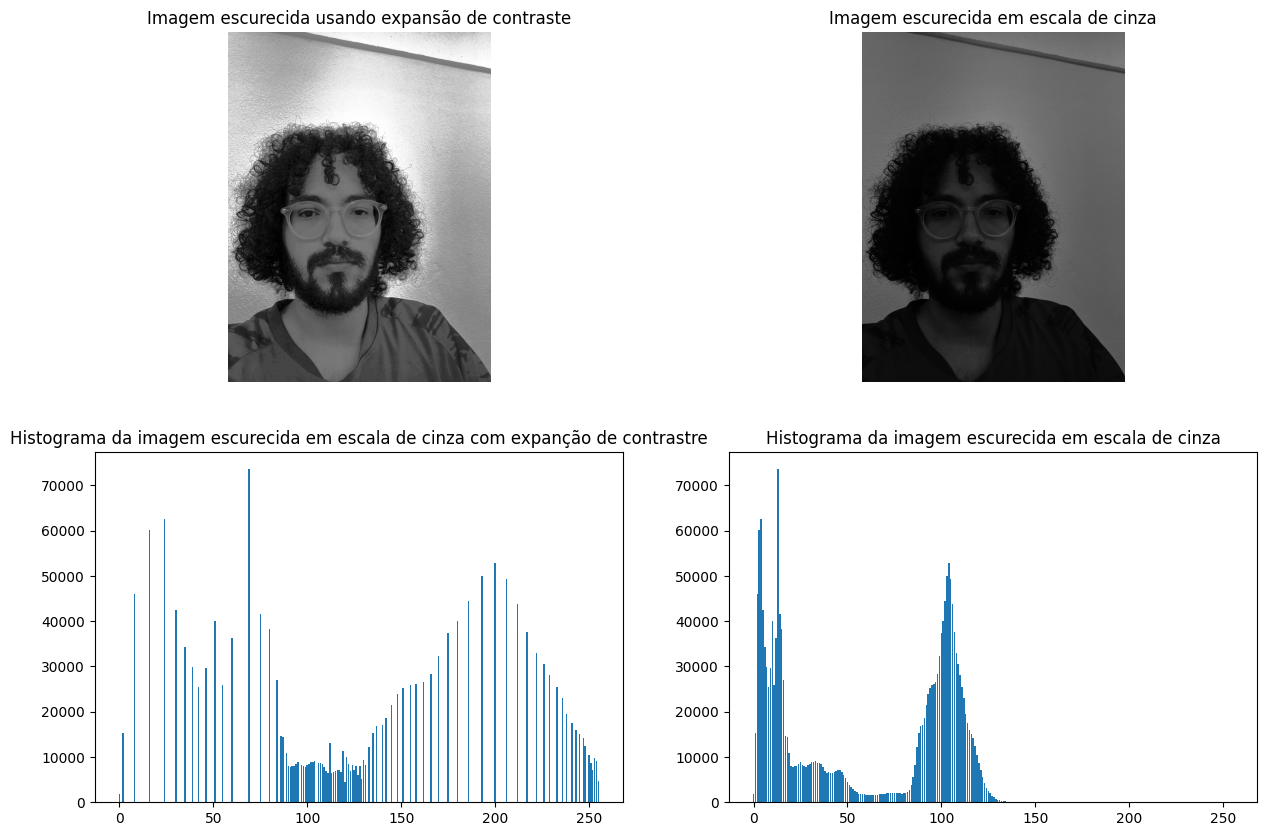

In [62]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.title('Imagem escurecida usando expansão de contraste')
plt.imshow(cv2.cvtColor(nova_imagem_escurecida, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,2,2)
plt.title('Imagem escurecida em escala de cinza')
plt.imshow(cv2.cvtColor(img_escurecida_gray, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,2,3)
plt.title('Histograma da imagem escurecida em escala de cinza com expanção de contrastre')
plt.bar(range(256),hist_img_escurecida_equalizada)

plt.subplot(2,2,4)
plt.title('Histograma da imagem escurecida em escala de cinza')
plt.bar(range(256),hist_img_escurecida)

##Imagem estourada

<BarContainer object of 256 artists>

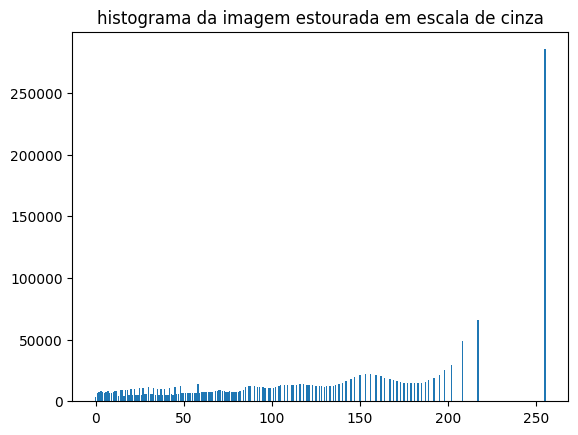

In [68]:
nova_imagem_estourada = equalizacao_histograma_opencv(img_estourada_gray)

hist_img_estourada_equalizada = calc_hist(nova_imagem_estourada)

plt.title('histograma da imagem estourada em escala de cinza')
plt.bar(range(256),hist_img_estourada_equalizada)

<BarContainer object of 256 artists>

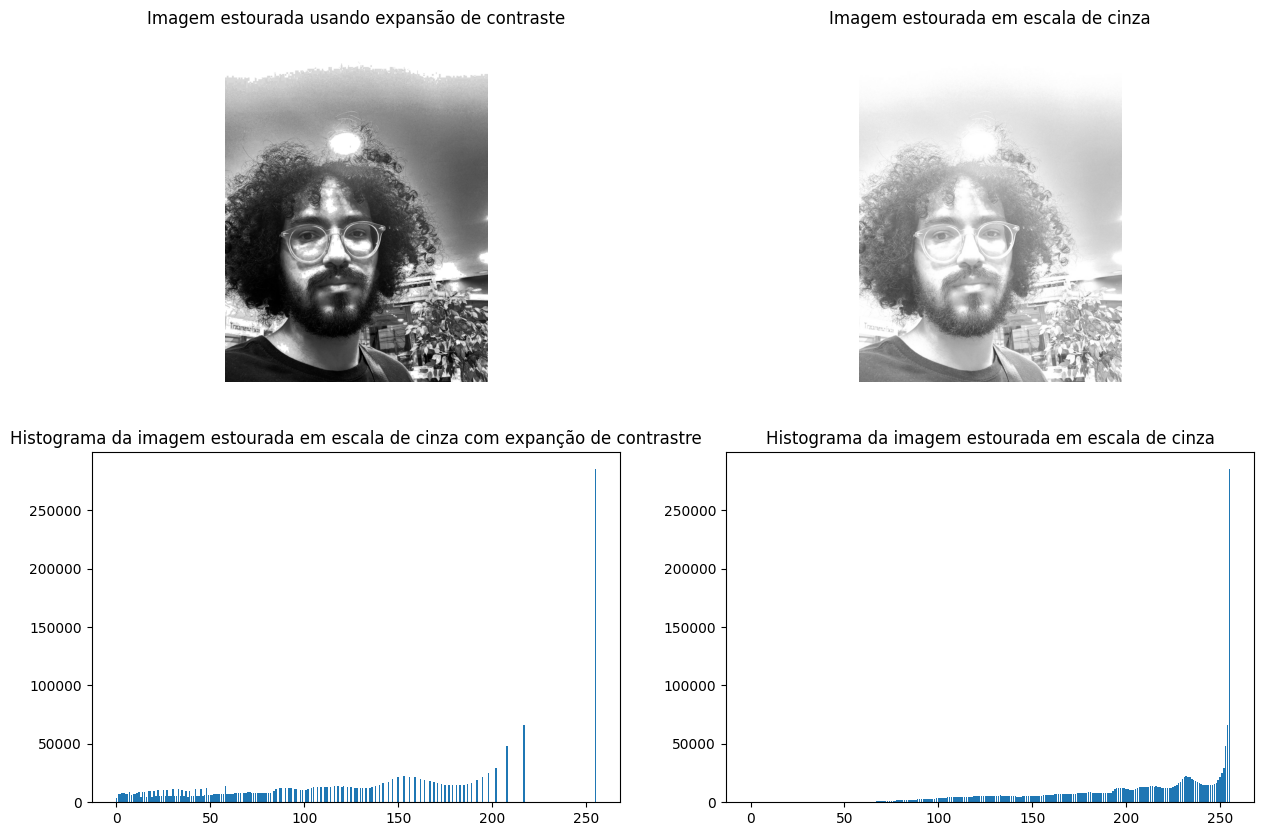

In [69]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.title('Imagem estourada usando expansão de contraste')
plt.imshow(cv2.cvtColor(nova_imagem_estourada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,2,2)
plt.title('Imagem estourada em escala de cinza')
plt.imshow(cv2.cvtColor(img_estourada_gray, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,2,3)
plt.title('Histograma da imagem estourada em escala de cinza com expanção de contrastre')
plt.bar(range(256),hist_img_estourada_equalizada)

plt.subplot(2,2,4)
plt.title('Histograma da imagem estourada em escala de cinza')
plt.bar(range(256),hist_img_estourada)

#Conclusão

Em qual das três imagens a operação fez menos
diferença? Por quê?

A operação fez menos diferença na foto normal, uma vez que por tem as condições "ideias" de luz os pixels já tendem a ser mais harmoniosos e grande parte se concentrando no centro do histograma, ou seja, sem muito preto e sem muito branco, numa real escala de cinza
